Monthly Milk Production Forecasting 
Using RNN, LSTM, and GRU Deep Learning Models


Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

Likely Business Problem:

The business wants to forecast future milk production to:
•	Ensure proper supply chain and distribution planning.
•	Manage inventory and storage efficiently.
•	Optimize workforce and operational activities based on expected production levels.
•	Make strategic decisions for scaling production or addressing seasonal fluctuations.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import keras

C:\Users\nagar\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
df = pd.read_csv("monthly_milk_production.csv")
print(df.shape)
df.head()

(168, 2)


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


1. EDA and Data Processing

In [6]:
'''
Checking the duplicate and missing values in the dataset
'''
print(df.duplicated().sum())
print(df.isnull().sum().sum())

0
0


<Axes: xlabel='Date', ylabel='Production'>

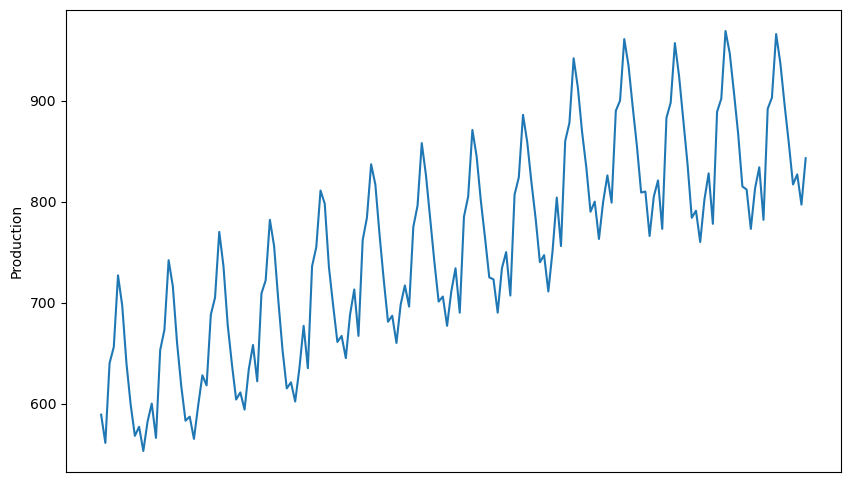

In [7]:
'''
Plotting the trends withing the production data
'''
plt.figure(figsize=(10, 6))
plt.gca().xaxis.set_visible(False)
sns.lineplot(x="Date", y="Production", data=df)

In [8]:
df.shape

(168, 2)

In [9]:
'''
Scaling
'''
min_max = MinMaxScaler()
train = min_max.fit_transform(df[["Production"]][:120])

In [10]:
'''
Getting the data into the required format with the window size of 10
'''
window_size = 10
x_train=[]
y_train=[]
for i in range(window_size,len(train)):
  x_train.append(train[i-window_size:i,0])
  y_train.append(train[i,0])
x_train = np.array(x_train)
y_train = np.array(y_train)

In [11]:
print(x_train.shape)
print(y_train.shape)

(110, 10)
(110,)


In [12]:
'''
np_array.reshape(batch_size, height, width)
'''
x_train = x_train.reshape(x_train.shape[0],x_train.shape[1],1)
x_train.shape

(110, 10, 1)

In [13]:
x_train

array([[[0.09254499],
        [0.02056555],
        [0.22365039],
        ...,
        [0.11825193],
        [0.03856041],
        [0.06169666]],

       [[0.02056555],
        [0.22365039],
        [0.26478149],
        ...,
        [0.03856041],
        [0.06169666],
        [0.        ]],

       [[0.22365039],
        [0.26478149],
        [0.44730077],
        ...,
        [0.06169666],
        [0.        ],
        [0.07455013]],

       ...,

       [[0.50899743],
        [0.64524422],
        [0.5218509 ],
        ...,
        [0.81233933],
        [0.72236504],
        [0.6092545 ]],

       [[0.64524422],
        [0.5218509 ],
        [0.78920308],
        ...,
        [0.72236504],
        [0.6092545 ],
        [0.63496144]],

       [[0.5218509 ],
        [0.78920308],
        [0.83547558],
        ...,
        [0.6092545 ],
        [0.63496144],
        [0.53984576]]])

2. Model Building

In [14]:
rnn= tf.keras.models.Sequential()

#### First hidden layer and Input layers
rnn.add(tf.keras.layers.SimpleRNN(units=50,return_sequences=True,input_shape=(10,1)))
rnn.add(tf.keras.layers.Dropout(0.2))
#### Second hidden layer
rnn.add(tf.keras.layers.SimpleRNN(units=50,return_sequences=True))
rnn.add(tf.keras.layers.Dropout(0.2))
#### Third Hidden layer
rnn.add(tf.keras.layers.SimpleRNN(units=50))
#### output layer
rnn.add(tf.keras.layers.Dense(1))

C:\Users\nagar\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
rnn.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [16]:
history = rnn.fit(x_train,y_train,epochs=20,batch_size=10)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2645
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1342 
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0686 
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0547 
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0503
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0429
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0361
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0316
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0204
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0221
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0248 
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0162
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0209 
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0199
Epoch 15/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0187
Epoch

In [17]:
rnn.evaluate(x_train,y_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 


0.005196436308324337

In [18]:
test = min_max.transform(df[["Production"]][168 - (48 + 10):])

x_test=[]
y_test=[]
for i in range(window_size,len(test)):
  x_test.append(test[i-window_size:i,0])
  y_test.append(test[i,0])
x_test= np.array(x_test)
y_test= np.array(y_test)

In [19]:
rnn_pred = rnn.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step


In [20]:
rnn_pred_inverse = min_max.inverse_transform(rnn_pred)

In [21]:
rnn_pred_inverse.shape

(48, 1)

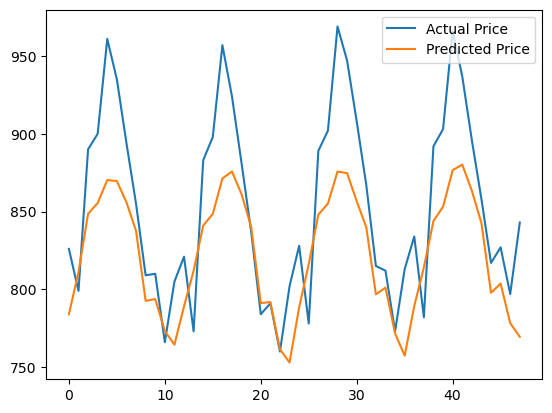

In [22]:
plt.plot(np.array(df["Production"][120:]),label='Actual Price')
plt.plot(rnn_pred_inverse,label='Predicted Price')
plt.legend()

In [23]:
lstm= tf.keras.models.Sequential()

#### First hidden layer and Input layers
lstm.add(tf.keras.layers.LSTM(units=50,return_sequences=True,input_shape=(10,1)))
lstm.add(tf.keras.layers.Dropout(0.2))
#### Second hidden layer
lstm.add(tf.keras.layers.LSTM(units=50,return_sequences=True))
lstm.add(tf.keras.layers.Dropout(0.2))
#### Third Hidden layer
lstm.add(tf.keras.layers.LSTM(units=50))
#### output layer
lstm.add(tf.keras.layers.Dense(1))

C:\Users\nagar\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
lstm.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [25]:
history = lstm.fit(x_train,y_train,epochs=20,batch_size=10)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1036
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0451
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0422
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0381
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0402
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0383
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0375
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0389 
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0383
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0367
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0371
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0371
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0389
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0382
Epoch 15/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0365
Epoch

In [26]:
lstm.evaluate(x_train,y_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0364 


0.03643152117729187

In [27]:
lstm_pred = lstm.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step


In [28]:
lstm_pred_inverse = min_max.inverse_transform(lstm_pred)

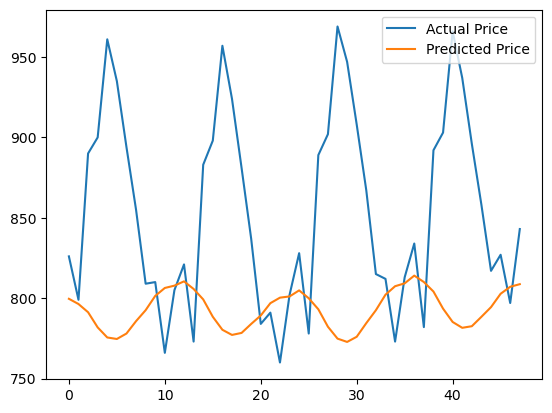

In [29]:
plt.plot(np.array(df["Production"][120:]),label='Actual Price')
plt.plot(lstm_pred_inverse,label='Predicted Price')
plt.legend()

In [30]:
gru= tf.keras.models.Sequential()

#### First hidden layer and Input layers
gru.add(tf.keras.layers.GRU(units=50,return_sequences=True,input_shape=(10,1)))
gru.add(tf.keras.layers.Dropout(0.2))
#### Second hidden layer
gru.add(tf.keras.layers.GRU(units=50,return_sequences=True))
gru.add(tf.keras.layers.Dropout(0.2))
#### Third Hidden layer
gru.add(tf.keras.layers.GRU(units=50))
#### output layer
gru.add(tf.keras.layers.Dense(1))

C:\Users\nagar\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
gru.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [32]:
history = gru.fit(x_train,y_train,epochs=20,batch_size=10)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1145
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0446
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0388
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0393
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0337
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0313
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0328
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0295
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0271 
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0284
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0261 
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0260
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0275 
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0219
Epoch 15/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0200
Epoch

In [33]:
gru.evaluate(x_train,y_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0098 


0.00980368722230196

In [34]:
gru_pred = gru.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


In [35]:
gru_pred_inverse = min_max.inverse_transform(gru_pred)

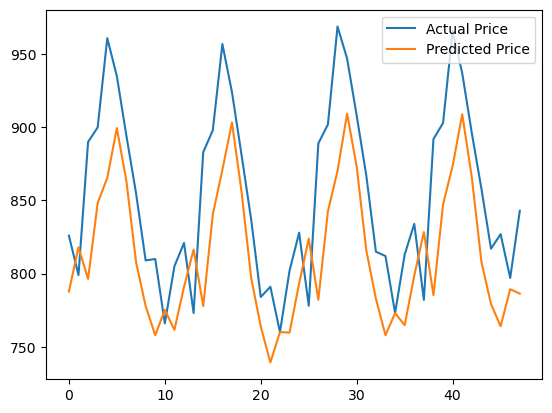

In [36]:
plt.plot(np.array(df["Production"][120:]),label='Actual Price')
plt.plot(gru_pred_inverse,label='Predicted Price')
plt.legend()